# Smoking & Birth Weight Analysis
Investigating the relationship between maternal smoking and infant birth weight using OLS regression.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.iolib.summary2 import summary_col

import warnings
warnings.filterwarnings('ignore')

sns.set_palette("husl")
sns.set_style("ticks")
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'

## Helper Functions

In [2]:
def fit_and_plot(formula, data, model_name="Model", x_var=None):
    model = smf.ols(formula=formula, data=data).fit()

    # ── Compact summary ───────────────────────────────────────────────────────
    rse = np.sqrt(model.mse_resid)
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  R²: {model.rsquared:.4f}    Adj R²: {model.rsquared_adj:.4f}    Residual SE: {rse:.4f}")
    print(f"  Observations: {int(model.nobs)}    df residual: {int(model.df_resid)}")
    print(f"{'-'*55}")
    print(f"  {'Coefficient':<20} {'Estimate':>10} {'Std Err':>10} {'t':>8} {'P>|t|':>8}")
    print(f"{'-'*55}")
    for name, coef, se, tval, pval in zip(
        model.params.index,
        model.params,
        model.bse,
        model.tvalues,
        model.pvalues
    ):
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "." if pval < 0.1 else ""
        print(f"  {name:<20} {coef:>10.4f} {se:>10.4f} {tval:>8.3f} {pval:>8.4f} {sig}")
    print(f"{'='*55}\n")

    if x_var is None:
        x_var = formula.split('~')[1].strip().split('+')[0].strip()

    y_var     = formula.split('~')[0].strip()
    
    # ── Use only rows that were actually used in the model (drops NaNs) ───────
    used_idx  = model.fittedvalues.index
    x_data    = data.loc[used_idx, x_var]
    y_data    = data.loc[used_idx, y_var]
    residuals = model.resid
    is_cat    = data[x_var].dtype == object or str(data[x_var].dtype) == 'category'

    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])
    ax_res  = fig.add_subplot(gs[1, 0])
    ax_qq   = fig.add_subplot(gs[1, 1])

    # ── 1. Actual vs Predicted ────────────────────────────────────────────────
    if is_cat:
        sns.stripplot(x=x_data, y=y_data,
                      alpha=0.3, color='black', s=4, ax=ax_main, label='Actual')
        group_means = y_data.groupby(x_data).mean()
        ax_main.hlines(group_means.values,
                       xmin=[i - 0.3 for i in range(len(group_means))],
                       xmax=[i + 0.3 for i in range(len(group_means))],
                       colors='red', linewidth=2, label='Predicted mean')
    else:
        ax_main.scatter(x_data, y_data,
                        alpha=0.3, color='black', s=15, label='Actual')
        ax_main.scatter(x_data, model.fittedvalues,
                        alpha=0.3, color='red', s=15, label='Predicted')

    ax_main.set_title(f'Actual vs Predicted — x: {x_var}', fontsize=13)
    ax_main.set_xlabel(x_var)
    ax_main.set_ylabel(y_var)
    ax_main.legend()

    # ── 2. Residuals vs Fitted ────────────────────────────────────────────────
    ax_res.scatter(model.fittedvalues, residuals,
                   alpha=0.3, color='steelblue', s=15)
    ax_res.axhline(0, color='red', linewidth=1, linestyle='--')
    ax_res.set_title('Residuals vs Fitted', fontsize=11)
    ax_res.set_xlabel('Fitted Values')
    ax_res.set_ylabel('Residuals')

    # ── 3. Q-Q plot ───────────────────────────────────────────────────────────
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax_qq.scatter(osm, osr, alpha=0.3, color='steelblue', s=15)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color='red', linewidth=1, linestyle='--')
    ax_qq.set_title('Q-Q Plot of Residuals', fontsize=11)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

    # ── Suptitle with all three stats ─────────────────────────────────────────
    plt.suptitle(
        f'{model_name}  |  R² = {model.rsquared:.3f}  |  Adj R² = {model.rsquared_adj:.3f}  |  Residual SE = {rse:.3f}',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()

    return model


def two_sample_ttest_summary(a, b, col, label_a, label_b):
    """
    Welch two-sample t-test with R-style output:
    n, mean, std, diff, 95% CI, t, df, p-value with significance stars.
    """
    x, y = a[col].dropna(), b[col].dropna()
    t, p = stats.ttest_ind(x, y, equal_var=False)
    df_w = (x.var()/len(x) + y.var()/len(y))**2 / (
            (x.var()/len(x))**2/(len(x)-1) + (y.var()/len(y))**2/(len(y)-1))
    diff = x.mean() - y.mean()
    se   = np.sqrt(x.var()/len(x) + y.var()/len(y))
    ci   = stats.t.interval(0.95, df=df_w, loc=diff, scale=se)

    print(f"--- Welch Two-Sample T-Test: {col} | {label_a} vs {label_b} ---")
    print(f"  n         : {len(x)}  vs  {len(y)}")
    print(f"  mean      : {x.mean():,.4f}  vs  {y.mean():,.4f}")
    print(f"  std       : {x.std(ddof=1):,.4f}  vs  {y.std(ddof=1):,.4f}")
    print(f"  diff      : {diff:,.4f}  ({label_a} minus {label_b})")
    print(f"  95% CI    : [{ci[0]:,.4f}, {ci[1]:,.4f}]")
    print(f"  t         : {t:.4f}")
    print(f"  df        : {df_w:.2f}")
    print(f"  p-value   : {p:.6f}  {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}")

print("✅ Helper functions defined.")

✅ Helper functions defined.


## 1. Load & Inspect Data

In [3]:
smoking_birth_weight = pd.read_csv("https://raw.githubusercontent.com/kostis-christodoulou/data_analytics_executives/main/data/smoking_birth_weight.csv")


print("Shape:", smoking_birth_weight.shape)
print("\nMissing values:")
print(smoking_birth_weight.isnull().sum())
smoking_birth_weight.describe().round(3)

Shape: (1000, 12)

Missing values:
father_age        171
mother_age          0
mature              0
weeks               2
premie              2
visits              9
lowbirthweight      0
gender              0
habit               1
whitemom            2
weight_kg           0
gained_kg          27
dtype: int64


,father_age,mother_age,weeks,visits,weight_kg,gained_kg
count,829.000,1000.000,998.000,991.000,1000.000,973.000
mean,30.256,27.000,38.335,12.105,3.224,13.784
std,6.764,6.214,2.932,3.955,0.685,6.473
min,14.000,13.000,20.000,0.000,0.454,0.000
25%,25.000,22.000,37.000,10.000,2.897,9.091
50%,30.000,27.000,39.000,12.000,3.319,13.636
75%,35.000,32.000,40.000,15.000,3.659,17.273
max,55.000,50.000,45.000,30.000,5.334,38.636


## 2. Smoking Habit Counts & Proportions

In [4]:
print("Counts:")
display(smoking_birth_weight['habit'].value_counts().to_frame())

print("\nProportions:")
display(smoking_birth_weight['habit'].value_counts(normalize=True).to_frame().round(3))

Counts:


,count
habit,
nonsmoker,873
smoker,126



Proportions:


,proportion
habit,
nonsmoker,0.874
smoker,0.126


## 3. Birth Weight by Smoking Habit

In [ ]:
display(
    smoking_birth_weight.groupby('habit')['weight_kg']
    .describe().round(3)
cat_cols = df_fixed.select_dtypes(include=['object', 'string', 'category']).columns
df_fixed[cat_cols] = df_fixed[cat_cols].astype('object')  # Ensure uniform object
)

,count,mean,std,min,25%,50%,75%,max
habit,,,,,,,,
nonsmoker,873.0,3.243,0.689,0.454,2.924,3.319,3.659,5.334
smoker,126.0,3.100,0.629,0.767,2.759,3.205,3.512,4.172


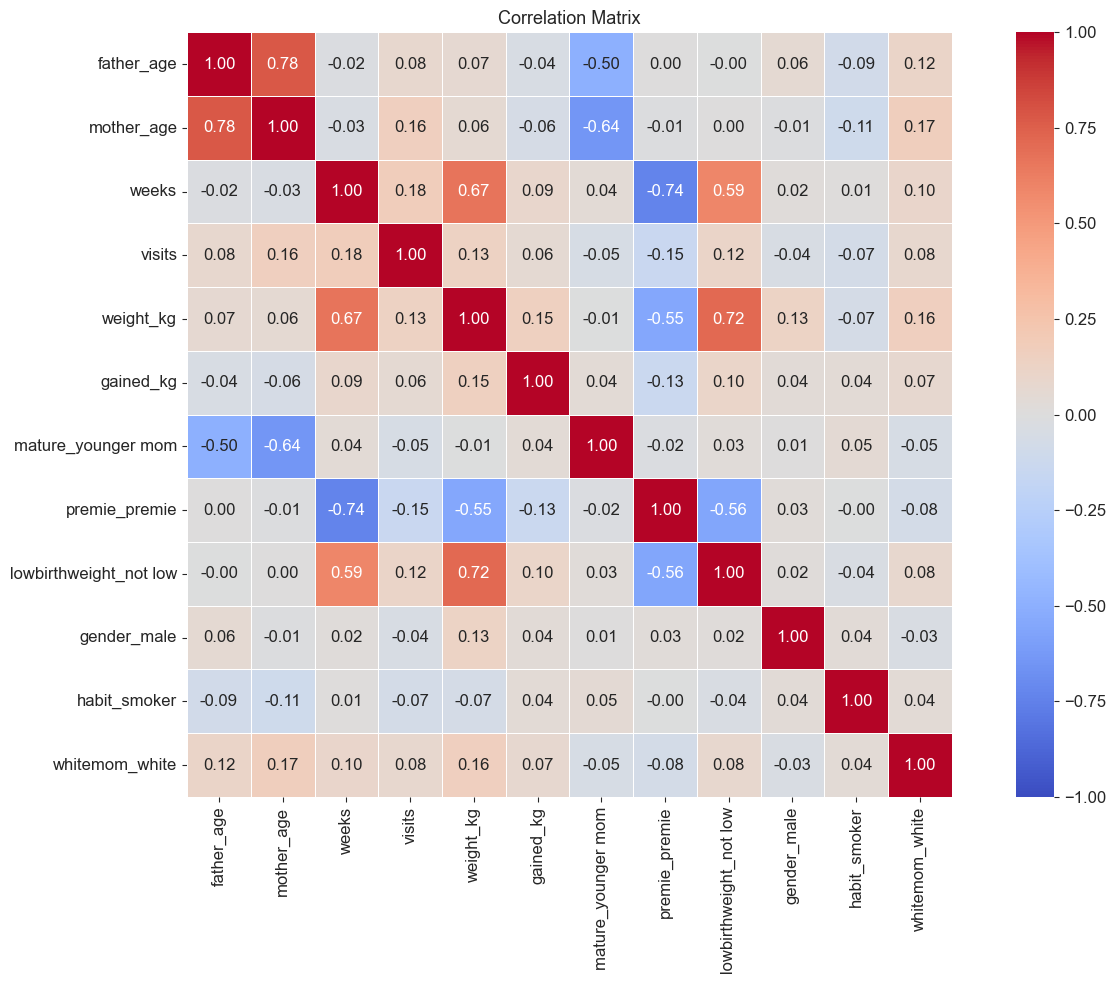

In [ ]:
# Target object, string, and category dtypes explicitly
df_fixed = smoking_birth_weight.copy()
cat_cols = df_fixed.select_dtypes(include=['object', 'string', 'category']).columns
df_fixed[cat_cols] = df_fixed[cat_cols].astype('object')  # Ensure uniform object

# Now get_dummies will pick them up
df_encoded = pd.get_dummies(df_fixed, drop_first=True, dtype=int)

numeric_cols = df_encoded.select_dtypes(include='number').columns

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    df_encoded[numeric_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Welch Two-Sample T-Test
Using the `two_sample_ttest_summary` helper.

In [20]:
two_sample_ttest_summary(
    smoking_birth_weight.query("habit == 'smoker'").to_frame() if isinstance(smoking_birth_weight.query("habit == 'smoker'"), pd.Series)
    else smoking_birth_weight.query("habit == 'smoker'"),
    smoking_birth_weight.query("habit == 'nonsmoker'"),
    col='weight_kg',
    label_a='Smoker',
    label_b='Non-smoker'
)

--- Welch Two-Sample T-Test: weight_kg | Smoker vs Non-smoker ---
  n         : 126  vs  873
  mean      : 3.1002  vs  3.2435
  std       : 0.6293  vs  0.6895
  diff      : -0.1433  (Smoker minus Non-smoker)
  95% CI    : [-0.2631, -0.0234]
  t         : -2.3590
  df        : 171.32
  p-value   : 0.019451  *


## 5. Model 1 — Intercept Only - Using the Mean to predict weight 
`weight_kg ~ 1`

In [21]:
model1 = smf.ols('weight_kg ~ 1', data=smoking_birth_weight).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              weight_kg   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 24 Mar 2026   Prob (F-statistic):                nan
Time:                        21:06:44   Log-Likelihood:                -1040.1
No. Observations:                1000   AIC:                             2082.
Df Residuals:                     999   BIC:                             2087.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.2239      0.022    148.823      0.0

## 6. Model 2 — Habit Only
`weight_kg ~ habit`


  M2: Habit Only
  R²: 0.0048    Adj R²: 0.0038    Residual SE: 0.6822
  Observations: 999    df residual: 997
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept                3.2435     0.0231  140.472   0.0000 ***
  habit[T.smoker]         -0.1433     0.0650   -2.203   0.0278 *



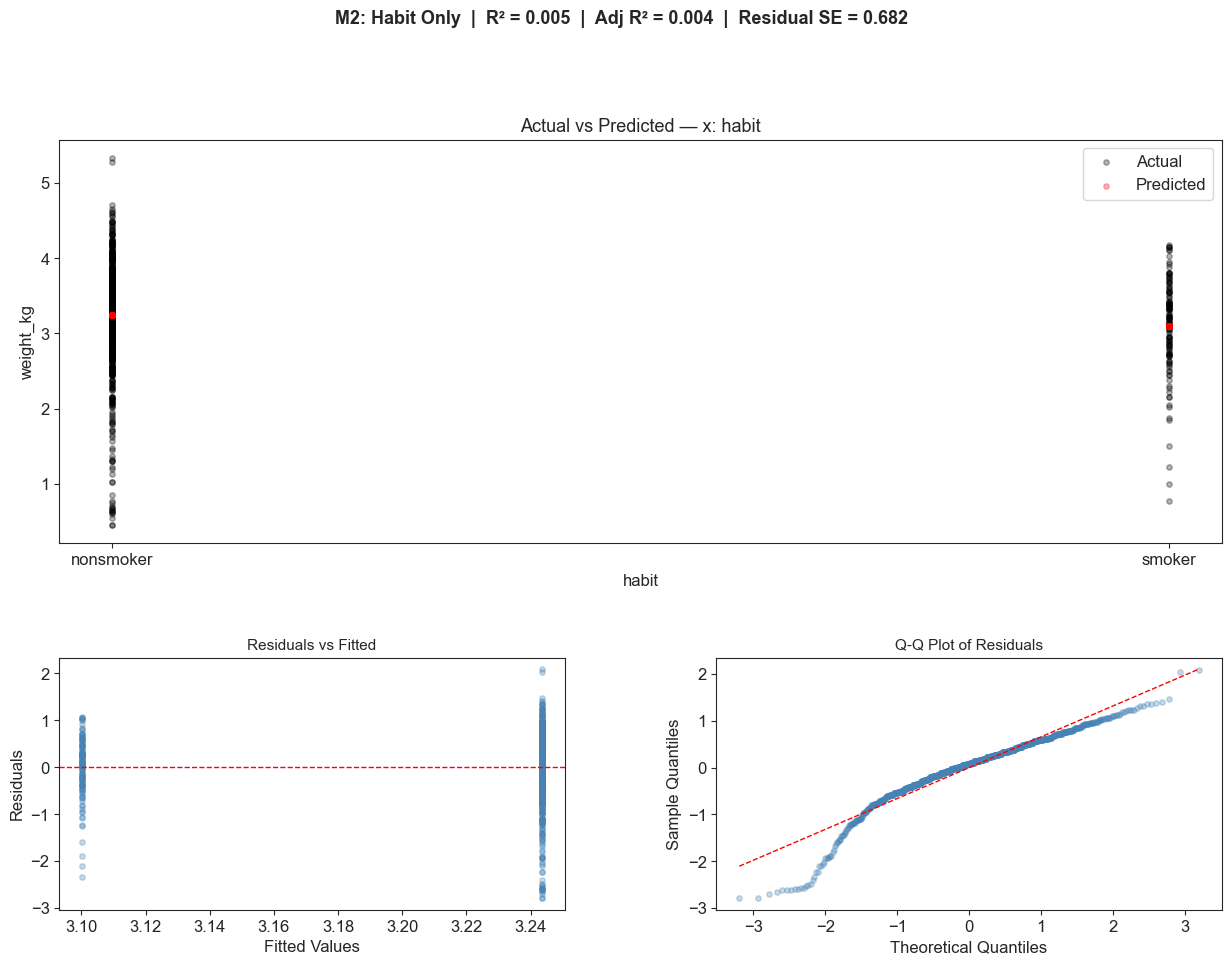

In [22]:
model2 = fit_and_plot(
    formula='weight_kg ~ habit',
    data=smoking_birth_weight,
    model_name='M2: Habit Only',
    x_var='habit'
)

## 7. Model 3 — Weeks + Habit
`weight_kg ~ weeks + habit`


  M3: Weeks + Habit
  R²: 0.4553    Adj R²: 0.4542    Residual SE: 0.5052
  Observations: 998    df residual: 995
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept               -2.7568     0.2099  -13.135   0.0000 ***
  habit[T.smoker]         -0.1629     0.0482   -3.383   0.0007 ***
  weeks                    0.1566     0.0055   28.685   0.0000 ***



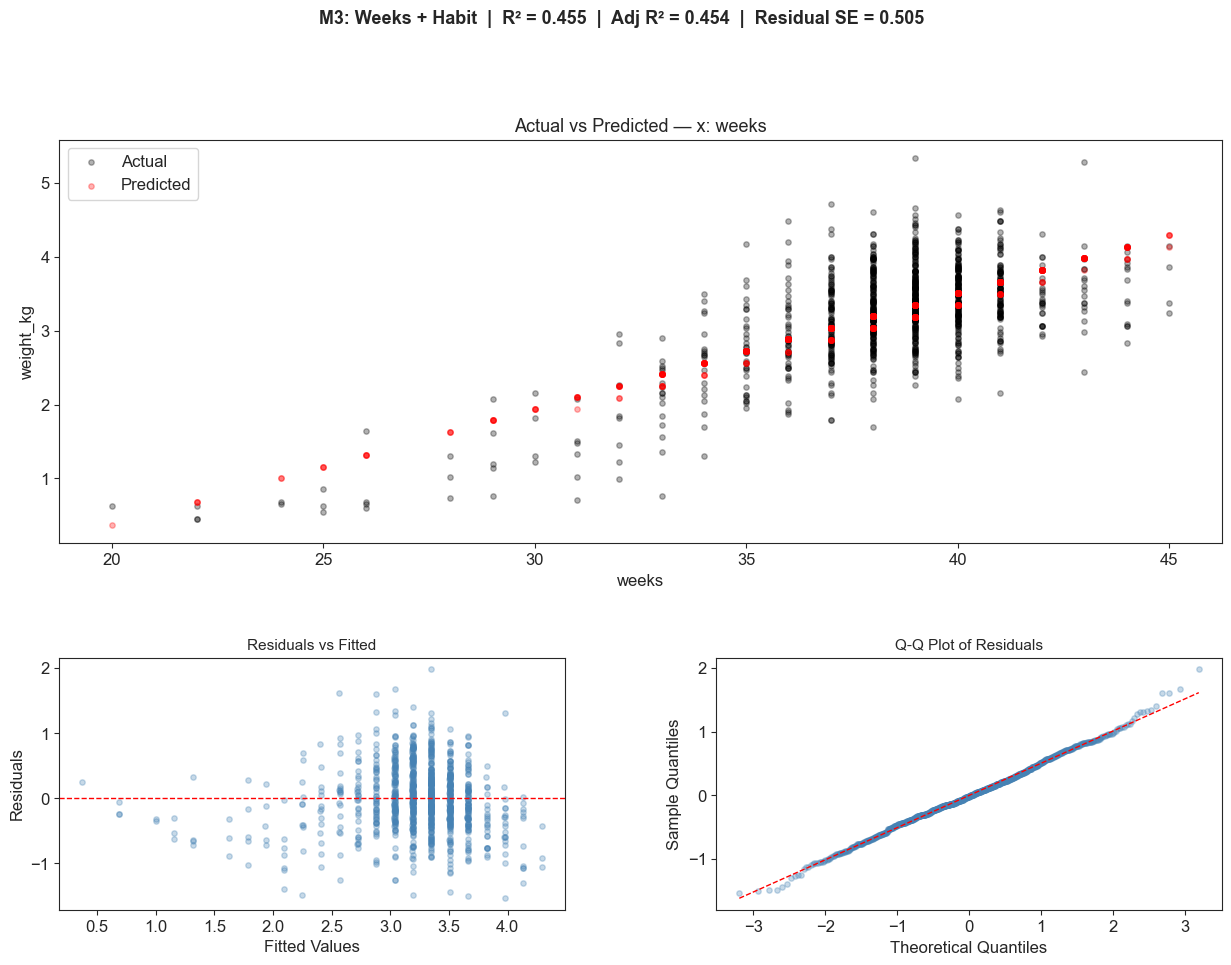

In [23]:
model3 = fit_and_plot(
    formula='weight_kg ~ weeks + habit',
    data=smoking_birth_weight,
    model_name='M3: Weeks + Habit',
    x_var='weeks'
)

## 8. Model 4 — Weeks + Habit + Controls
`weight_kg ~ weeks + habit + gender + whitemom + gained_kg`


  M4: Weeks + Habit + Controls
  R²: 0.4803    Adj R²: 0.4776    Residual SE: 0.4890
  Observations: 970    df residual: 964
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept               -2.8159     0.2091  -13.465   0.0000 ***
  habit[T.smoker]         -0.1974     0.0475   -4.160   0.0000 ***
  gender[T.male]           0.1738     0.0315    5.518   0.0000 ***
  whitemom[T.white]        0.1394     0.0350    3.983   0.0001 ***
  weeks                    0.1501     0.0055   27.498   0.0000 ***
  gained_kg                0.0093     0.0024    3.793   0.0002 ***



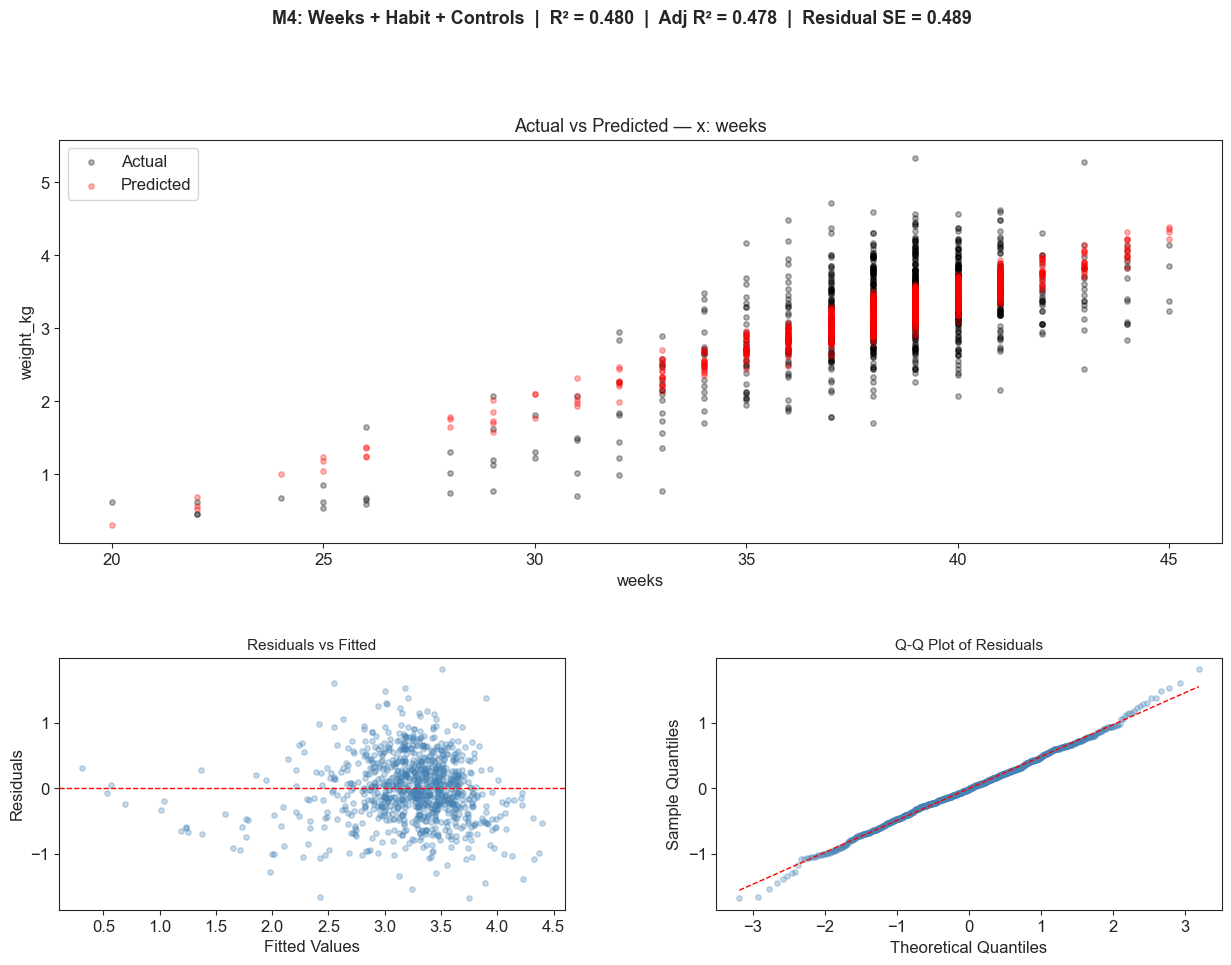

In [24]:
model4 = fit_and_plot(
    formula='weight_kg ~ weeks + habit + gender + whitemom + gained_kg',
    data=smoking_birth_weight,
    model_name='M4: Weeks + Habit + Controls',
    x_var='weeks'
)

## 9. Model 5 — All Variables


  M5: All Variables
  R²: 0.6038    Adj R²: 0.5983    Residual SE: 0.4147
  Observations: 800    df residual: 788
-------------------------------------------------------
  Coefficient            Estimate    Std Err        t    P>|t|
-------------------------------------------------------
  Intercept               -1.2007     0.3362   -3.571   0.0004 ***
  habit[T.smoker]         -0.0982     0.0484   -2.028   0.0429 *
  whitemom[T.white]        0.1219     0.0357    3.412   0.0007 ***
  gender[T.male]           0.1731     0.0296    5.839   0.0000 ***
  mature[T.younger mom]     0.0129     0.0542    0.238   0.8122 
  premie[T.premie]        -0.0188     0.0653   -0.287   0.7739 
  lowbirthweight[T.not low]     1.0911     0.0648   16.834   0.0000 ***
  weeks                    0.0783     0.0082    9.494   0.0000 ***
  gained_kg                0.0069     0.0023    2.968   0.0031 **
  father_age               0.0040     0.0035    1.145   0.2524 
  mother_age               0.0022     0.0044  

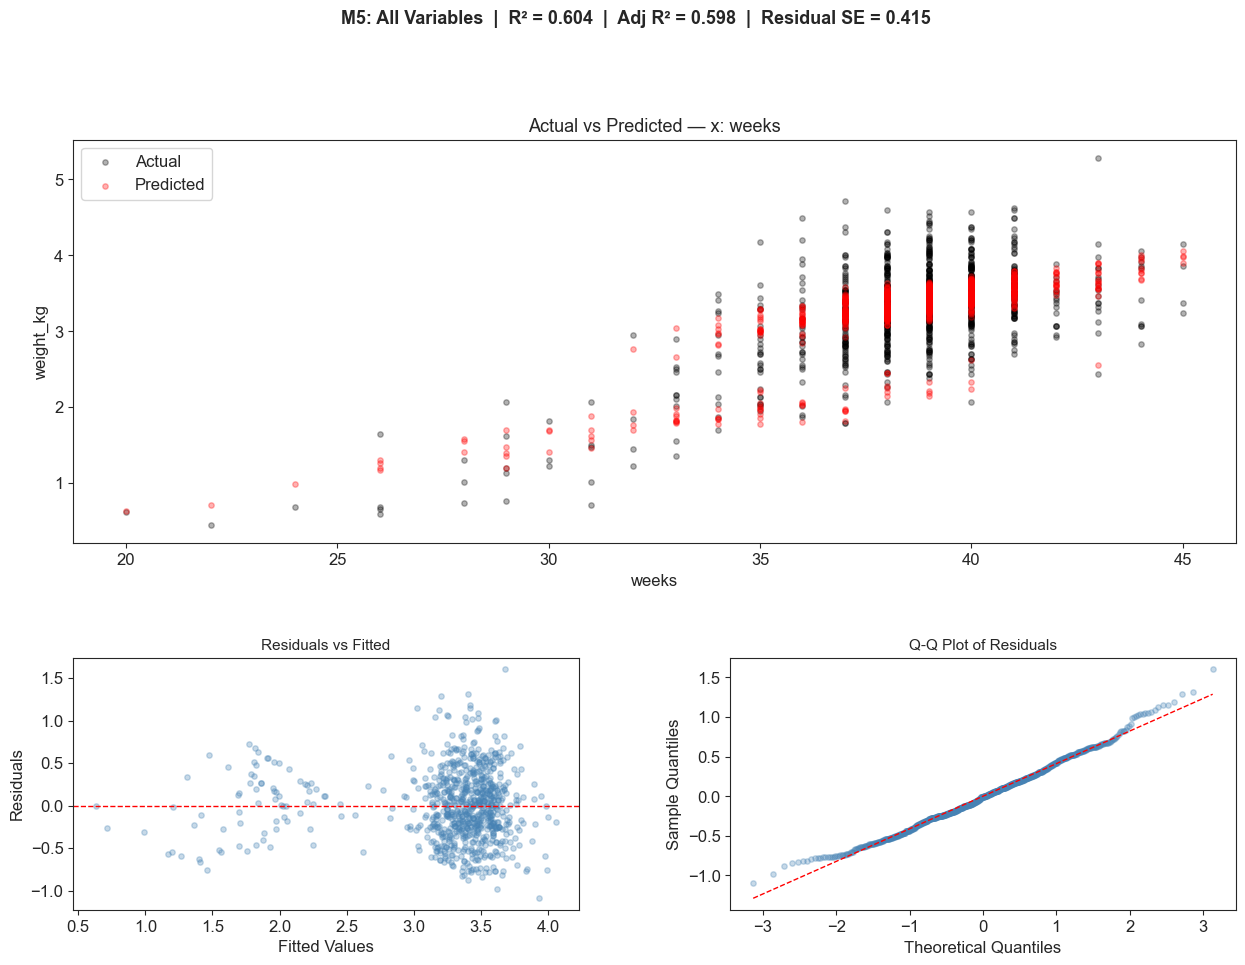

In [25]:
model5 = fit_and_plot(
    formula='weight_kg ~ weeks + habit + whitemom + gender + gained_kg + father_age + mother_age + mature + premie + visits + lowbirthweight',
    data=smoking_birth_weight,
    model_name='M5: All Variables',
    x_var='weeks'
)

## 10. Model Comparison

In [16]:
models = {
    'M1: ~1':                    model1,
    'M2: ~habit':                model2,
    'M3: ~weeks+habit':          model3,
    'M4: ~weeks+habit+controls': model4,
    'M5: ~all vars':             model5,
}

comparison = pd.DataFrame({
    name: {
        'N':           int(m.nobs),
        'R²':          round(m.rsquared, 4),
        'Adj. R²':     round(m.rsquared_adj, 4),
        'Residual SE': round(np.sqrt(m.mse_resid), 3),
        'AIC':         round(m.aic, 1),
    }
    for name, m in models.items()
})

display(comparison)

,M1: ~1,M2: ~habit,M3: ~weeks+habit,M4: ~weeks+habit+controls,M5: ~all vars
N,1000.000,999.0000,998.0000,970.0000,800.0000
R²,-0.000,0.0048,0.4553,0.4803,0.6038
Adj. R²,-0.000,0.0038,0.4542,0.4776,0.5983
Residual SE,0.685,0.6820,0.5050,0.4890,0.4150
AIC,2082.300,2073.0000,1472.5000,1370.7000,873.7000


## 11. Full Coefficient Table

In [17]:
summary = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,
    float_format='%0.3f',
    model_names=['M1', 'M2', 'M3', 'M4', 'M5'],
    info_dict={'Residual SE': lambda x: f"{x.scale ** 0.5:.3f}"}
)
print(summary)


                             M1       M2        M3        M4        M5   
-------------------------------------------------------------------------
Intercept                 3.224*** 3.243*** -2.757*** -2.816*** -1.201***
                          (0.022)  (0.023)  (0.210)   (0.209)   (0.336)  
habit[T.smoker]                    -0.143** -0.163*** -0.197*** -0.098** 
                                   (0.065)  (0.048)   (0.047)   (0.048)  
weeks                                       0.157***  0.150***  0.078*** 
                                            (0.005)   (0.005)   (0.008)  
gender[T.male]                                        0.174***  0.173*** 
                                                      (0.031)   (0.030)  
whitemom[T.white]                                     0.139***  0.122*** 
                                                      (0.035)   (0.036)  
gained_kg                                             0.009***  0.007*** 
                                     